# **Redes Neuronales Convolucionales**
### Actividad grupal

---

En esta actividad se trabajará con Redes Neuronales Convolucionales (Convolutional Neural Networks, CNN) para resolver un problema de clasificación de imágenes. En particular, se utilizará un conjunto de imágenes de mascotas, enfocándose en la clasificación de perros y gatos.

Dado que las CNN profundas son modelos computacionalmente demandantes, se recomienda realizar la práctica en Google Colaboratory, aprovechando el soporte para unidades de procesamiento gráfico (GPU). En el siguiente enlace se describe el procedimiento para habilitar una GPU en Colab:  
[Guía para activar GPU en Google Colab](https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d).

El conjunto de datos a utilizar es el **Oxford-IIIT Pet Dataset**, el cual contiene imágenes de distintas razas de perros y gatos. Su sitio oficial es:  
[Oxford-IIIT Pet Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/)

Este dataset es considerablemente más complejo que otros utilizados previamente, como Fashion MNIST, ya que:
- Incluye múltiples clases (razas),
- Presenta variaciones significativas en escala, pose e iluminación,
- Contiene imágenes con diferentes fondos y encuadres.

El conjunto de datos puede integrarse fácilmente a flujos de trabajo basados en frameworks de aprendizaje profundo como [Tensorflow](https://www.tensorflow.org/datasets/catalog/oxford_iiit_pet) y [PyTorch](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.OxfordIIITPet.html), ya sea mediante utilidades propias de cada framework o mediante descarga directa desde el sitio oficial.

Antes de iniciar el desarrollo del modelo, se recomienda descargar el dataset, explorar visualmente las imágenes y analizar su estructura, con el fin de comprender mejor los retos asociados al problema de clasificación.

## Librerías

In [ ]:
!pip install -U protobuf tensorflow_datasets tensorflow-metadata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 7.4 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.1 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.1 which is incompatible.


In [1]:
import cv2
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt
# Libreria para el dataset
import tensorflow_datasets as tfds

import seaborn as sns
import tensorflow as tf
from collections import Counter

In [2]:
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from keras.models import Sequential
from keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import time
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## Dataset

El dataset se encuentra la librería ***tfds***. En caso de no tener la líbrería instalarla mediante
```
# !pip install tensorflow-datasets
```
Las imágenes se descargan a través del método *load*, que tiene los siguientes parámetros:
* **split** indica la división del dataset, por ejemplo: "train" o ["train", "test"], ...
* **data_dir** ubicación donde se almacenan los datos, por dafault es ~/
* **with_info** devuelve los metadatos del dataset (tfds.core.DatasetInfo). Por default es *True*
* **download** deshabilita la descarga del dataset. Por default es False
* **as_supervised** descarga el dataset con su salida, variable y.

In [5]:
!pip install tensorflow-datasets

In [13]:
!pip install -U protobuf tensorflow_datasets tensorflow-metadata importlib_resources

In [3]:

IMG_SIZE = 160

split_data, info = tfds.load(
    'oxford_iiit_pet',
    data_dir = '../datasets/oxford_iiit_pet',    
    split=[
        'train[:80%]',      # entrenamiento
        'train[80%:90%]',   # validación
        'train[90%:]'],     # prueba
    with_info=True,
    as_supervised=True
)

train_ds, val_ds, test_ds = split_data

print("Clases:", info.features['label'].num_classes)
print("Nombres de clases:", info.features['label'].names)
print("Total de ejemplos:", info.splits['train'].num_examples)

Clases: 37
Nombres de clases: ['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'Bengal', 'Birman', 'Bombay', 'boxer', 'British_Shorthair', 'chihuahua', 'Egyptian_Mau', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'Maine_Coon', 'miniature_pinscher', 'newfoundland', 'Persian', 'pomeranian', 'pug', 'Ragdoll', 'Russian_Blue', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'Siamese', 'Sphynx', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']
Total de ejemplos: 3680


2026-09-14 19:12:50.250583: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-09-14 19:12:50.250724: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-09-14 19:12:50.250732: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
I0000 00:00:1789434770.251138 10759704 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1789434770.251179 10759704 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


El manejo de los datos del conjunto se realiza mediante la **API tf.data**, una herramienta de *TensorFlow* diseñada para construir *pipelines* de entrada de datos eficientes y escalables. Esta API es especialmente útil cuando se trabaja con conjuntos de datos de gran tamaño, ya que permite cargar y procesar la información en lotes pequeños (*batches*), optimizando el uso de recursos y mejorando el rendimiento durante el entrenamiento.

Cada conjunto de datos en **tf.data** se representa como un objeto de tipo `tf.data.Dataset`, el cual puede contener elementos en forma de tuplas o diccionarios de tensores (por ejemplo, `tf.float32`, `tf.int32`, `tf.string`). Esta estructura garantiza compatibilidad total con *TensorFlow* y facilita un procesamiento eficiente, ya que los datos se consumen de manera incremental durante el entrenamiento, reduciendo la necesidad de cargar todo el dataset en memoria al mismo tiempo.

### **Operaciones comunes en tf.data**

Las operaciones de `tf.data` pueden encadenarse para construir *pipelines* de procesamiento flexibles y eficientes. Algunas de las más utilizadas son:

* **map**: Aplica una función personalizada a cada elemento del `Dataset` (por ejemplo, normalización de imágenes o aumento de datos).
* **batch**: Agrupa los elementos en lotes de un tamaño especificado, lo que permite el entrenamiento por mini-lotes.
* **shuffle**: Mezcla aleatoriamente los elementos del `Dataset` utilizando un parámetro `buffer_size`. Un valor grande favorece una mejor aleatorización, especialmente en conjuntos de datos extensos.
* **repeat**: Repite el conjunto de datos un número determinado de veces, útil para controlar el número de épocas durante el entrenamiento.
* **prefetch**: Permite preparar los siguientes lotes mientras el modelo se encuentra entrenando, mejorando la utilización de recursos de CPU y GPU.

Para profundizar en el uso y configuración de estos métodos, se recomienda consultar la documentación oficial de [tf.data](https://www.tensorflow.org/guide/data).

2026-09-14 19:12:56.439600: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:376] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
2026-09-14 19:12:57.193844: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


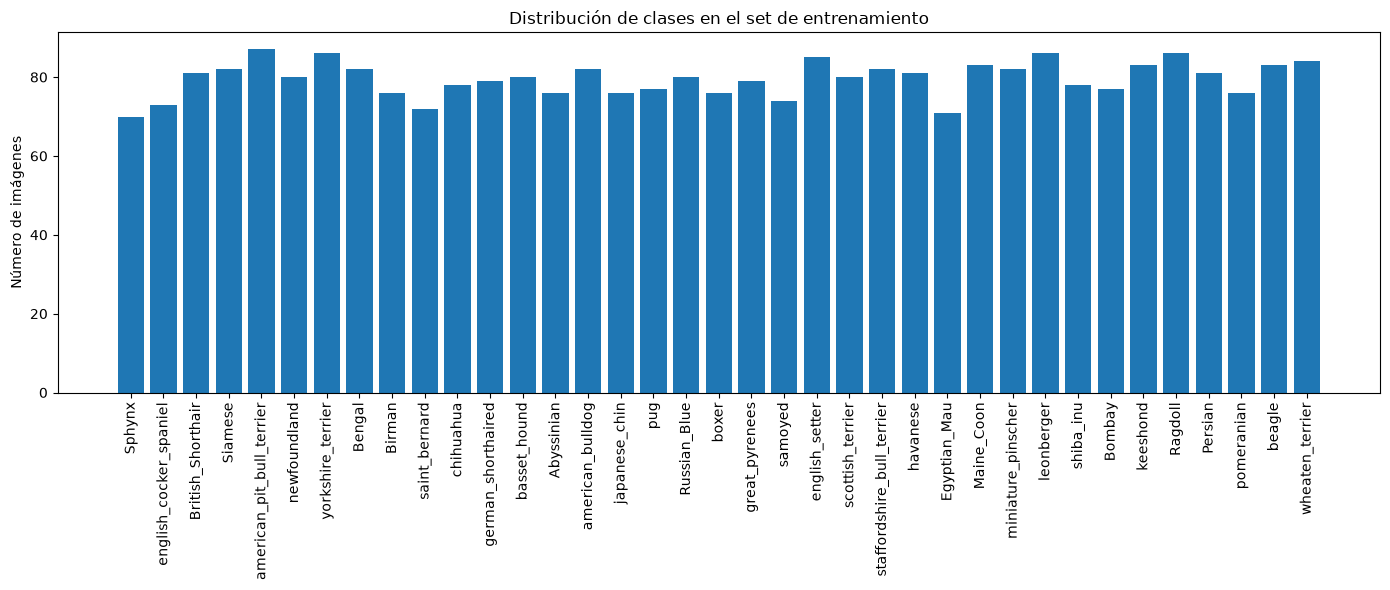

In [4]:
labels = [label.numpy() for _, label in train_ds]
conteo = Counter(labels)
nombres = info.features['label'].names

plt.figure(figsize=(14,6))
plt.bar([nombres[i] for i in conteo.keys()], conteo.values())
plt.xticks(rotation=90)
plt.title("Distribución de clases en el set de entrenamiento")
plt.ylabel("Número de imágenes")
plt.tight_layout()
plt.show()

In [5]:
print("Clase con más ejemplos:", nombres[max(conteo, key=conteo.get)], max(conteo.values()))
print("Clase con menos ejemplos:", nombres[min(conteo, key=conteo.get)], min(conteo.values()))

Clase con más ejemplos: american_pit_bull_terrier 87
Clase con menos ejemplos: Sphynx 70


In [ ]:
# Con 37 clases y ~99 imágenes promedio por clase (3,680/37), y un rango de 70 a 87 en el set de entrenamiento, el desbalance es leve (no hay una clase con 5x más datos que otra, por ejemplo)

2026-09-14 19:13:05.406307: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


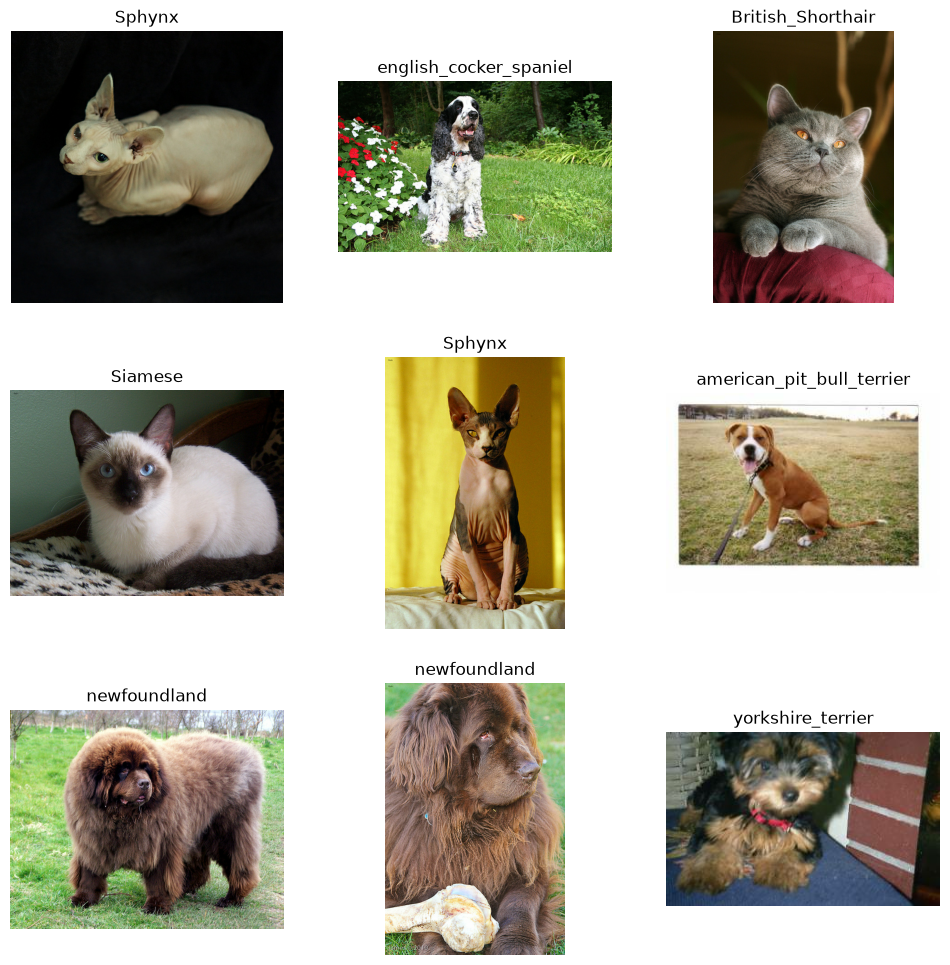

In [6]:
plt.figure(figsize=(12,12))
for i, (image, label) in enumerate(train_ds.take(9)):
    ax = plt.subplot(3, 3, i+1)
    plt.imshow(image.numpy().astype("uint8"))
    plt.title(nombres[label.numpy()])
    plt.axis("off")
plt.show()

In [7]:
alturas, anchos = [], []
for image, _ in train_ds.take(200):  # muestra representativa
    h, w, _ = image.shape
    alturas.append(h)
    anchos.append(w)

print("Alto - min/max/promedio:", min(alturas), max(alturas), np.mean(alturas))
print("Ancho - min/max/promedio:", min(anchos), max(anchos), np.mean(anchos))

image, label = next(iter(train_ds))
print("Rango de píxeles:", image.numpy().min(), "-", image.numpy().max())

Alto - min/max/promedio: 163 900 384.085
Ancho - min/max/promedio: 119 720 430.82
Rango de píxeles: 0 - 255


In [8]:
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0  # normalización a [0,1]
    return image, label

BATCH_SIZE = 32

train_ds_prep = (train_ds
                  .map(preprocess)
                  .shuffle(1000)
                  .batch(BATCH_SIZE)
                  .prefetch(tf.data.AUTOTUNE))

val_ds_prep = (val_ds
               .map(preprocess)
               .batch(BATCH_SIZE)
               .prefetch(tf.data.AUTOTUNE))

test_ds_prep = (test_ds
                .map(preprocess)
                .batch(BATCH_SIZE)
                .prefetch(tf.data.AUTOTUNE))

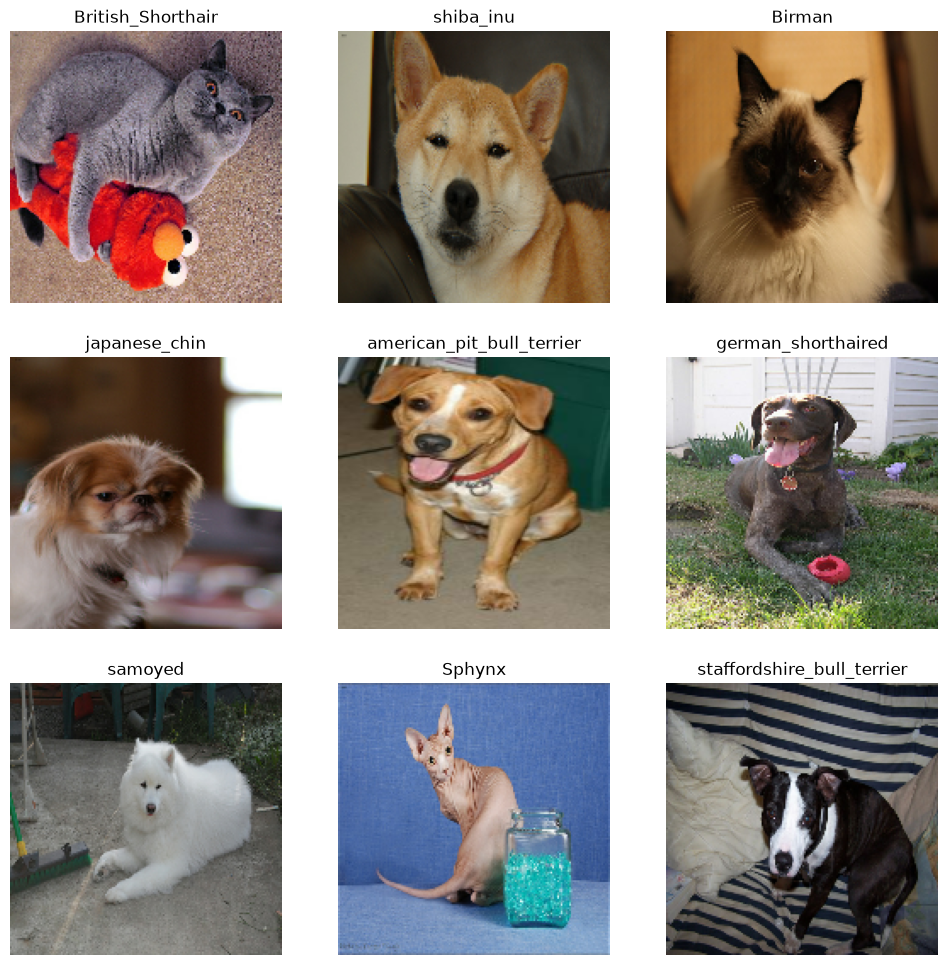

Rango de píxeles después de normalizar: 0.0 - 1.0


In [9]:
image_batch, label_batch = next(iter(train_ds_prep))

plt.figure(figsize=(12,12))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(image_batch[i])
    plt.title(nombres[label_batch[i].numpy()])
    plt.axis("off")
plt.show()

print("Rango de píxeles después de normalizar:", image_batch.numpy().min(), "-", image_batch.numpy().max())

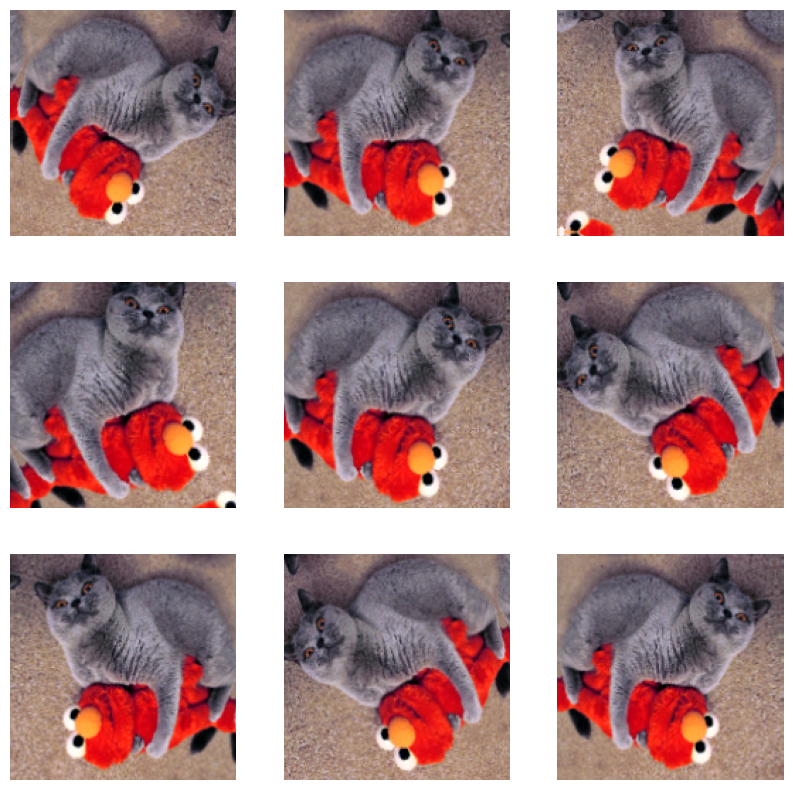

In [10]:
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
    keras.layers.RandomContrast(0.1),
])

plt.figure(figsize=(10,10))
for i in range(9):
    augmented = data_augmentation(image_batch)
    plt.subplot(3,3,i+1)
    plt.imshow(augmented[0])
    plt.axis("off")
plt.show()

In [ ]:
(train_ds, val_ds, test_ds) = split_data

## Ejercicio

Utilizando ***Convolutional Neural Networks*** (CNN) implementadas con Keras, entrenar un clasificador capaz de reconocer razas de perros y gatos en imágenes, alcanzando una accuracy en el conjunto de **test** de al menos **85%**. Es indispensable que el **mejor modelo seleccionado no presente evidencias de overfitting ni de underfitting**.

El desarrollo de la actividad debe apoyarse en un **proceso experimental riguroso**, documentado mediante un **informe técnico**, en el cual se analicen de manera comparativa las distintas estrategias exploradas y se justifiquen las decisiones adoptadas con base en los resultados obtenidos.

A continuación, se detallan los aspectos que deben ser abordados en el informe:
* **Análisis exploratorio de los datos utilizados**, considerando la distribución de clases, el tamaño del dataset, ejemplos representativos de las imágenes y la identificación de posibles desbalances.
* **Diseño y evaluación de al menos cuatro modelos**. Se espera que al menos uno de ellos corresponda a una arquitectura propuesta por los estudiantes. Adicionalmente, pueden emplearse modelos preentrenados mediante *transfer learning* o *fine-tuning*.
* **Análisis de resultados**, incluyendo métricas de *precision* y *recall* por clase y/o el uso de una matriz de confusión, con el fin de identificar qué clases presentan mejor o peor desempeño.
* **Análisis visual de los errores del modelo**, discutiendo qué tipos de imágenes o qué razas generan mayor confusión.
* **Comparación del desempeño de modelos basados en CNN frente a un modelo Fully Connected** (quinto modelo), considerando las imágenes aplanadas como entrada.
* **Entrenamiento y comparación de distintas arquitecturas CNN**, discutiendo aspectos como la profundidad de la red, hiperparámetros, optimizador, funciones de activación, uso de técnicas de regularización y batch normalization, entre otros.
* **Empleo de técnicas de data augmentation** y análisis de su impacto en el desempeño y la capacidad de generalización del modelo.

---
### **Notas importantes**

* Los conjuntos de **training** y **validation** deben emplearse durante el entrenamiento y ajuste de los modelos. El conjunto de **test** debe utilizarse **exclusivamente para la evaluación final del desempeño**.
* Evitar el reentrenamiento de los modelos, salvar el mejor modelo de cada modelo empleado, para que en caso de ser necesario se realicen las predicciones sin necesidad de emplear GPU.
* Es obligatorio verificar que el modelo no presente **overfitting**, apoyándose en el análisis de las curvas de entrenamiento y validación.
* No es necesario mostrar en el notebook las trazas de entrenamiento de todos los modelos evaluados. No obstante, se recomienda conservar las gráficas de entrenamiento para sustentar el análisis en el informe. **De manera obligatoria, debe mostrarse el entrenamiento completo y la evaluación sobre el conjunto de test del mejor modelo obtenido**.
* Las imágenes **no se encuentran normalizadas**, por lo que es necesario aplicar un proceso de normalización previo al entrenamiento del modelo.

---
### **Notas adicionales**

* Con el fin de **optimizar el uso de recursos computacionales**, se debe **evitar el reentrenamiento innecesario de los modelos**. Para cada arquitectura evaluada, es obligatorio **guardar el mejor modelo obtenido**, utilizando como criterio su desempeño sobre el conjunto de validación.
* En caso de requerir nuevas predicciones, análisis de errores o comparaciones adicionales, estas deberán realizarse **cargando los modelos previamente almacenados**, sin necesidad de volver a entrenarlos ni de emplear GPU.
* Para garantizar la **reproducibilidad de los experimentos**, se recomienda fijar de manera consistente las semillas aleatorias (*random seeds*) asociadas al entrenamiento, así como documentar los hiperparámetros, configuraciones del optimizador y criterios de parada utilizados en cada modelo.
* La **trazabilidad experimental** debe quedar reflejada en el notebook y en el informe técnico, de modo que sea posible identificar claramente qué configuraciones dieron lugar a cada resultado reportado. Esto incluye la asociación explícita entre modelos entrenados, métricas obtenidas, curvas de entrenamiento y conclusiones derivadas.

In [11]:
from keras import layers, models

def crear_modelo_cnn():
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        data_augmentation,  # solo se aplica durante entrenamiento

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(37, activation='softmax')  # 37 clases
    ])
    return model

modelo1 = crear_modelo_cnn()
modelo1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 20, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │         9,509 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,528,805 (13.46 MB)

 Trainable params: 3,528,101 (13.46 MB)

 Non-trainable params: 704 (2.75 KB)

In [12]:
modelo1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # porque los labels son enteros, no one-hot
    metrics=['accuracy']
)

In [13]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    '../keras/modelo1_mejor.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

In [14]:
historia1 = modelo1.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=50,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/50


/Users/fvcg/projects/uni-cognit-systems/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-09-14 19:15:12.942850: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.0360 - loss: 33.0966
Epoch 1: val_accuracy improved from None to 0.02717, saving model to ../keras/modelo1_mejor.keras

Epoch 1: finished saving model to ../keras/modelo1_mejor.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 130ms/step - accuracy: 0.0360 - loss: 33.0966 - val_accuracy: 0.0272 - val_loss: 9.3412
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.0374 - loss: 42.0444
Epoch 2: val_accuracy did not improve from 0.02717
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - accuracy: 0.0374 - loss: 42.0444 - val_accuracy: 0.0217 - val_loss: 22.9746
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.0472 - loss: 43.2200
Epoch 3: val_accuracy improved from 0.02717 to 0.04620, saving model to ../keras/modelo1_mejor.keras

Epoch 3: finished saving model to ../keras/modelo1_mejor.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - accuracy: 0.0472 - loss: 43.2200 - val_accuracy: 0.0462 - val_loss: 21.7427
Epoch 4/50
92

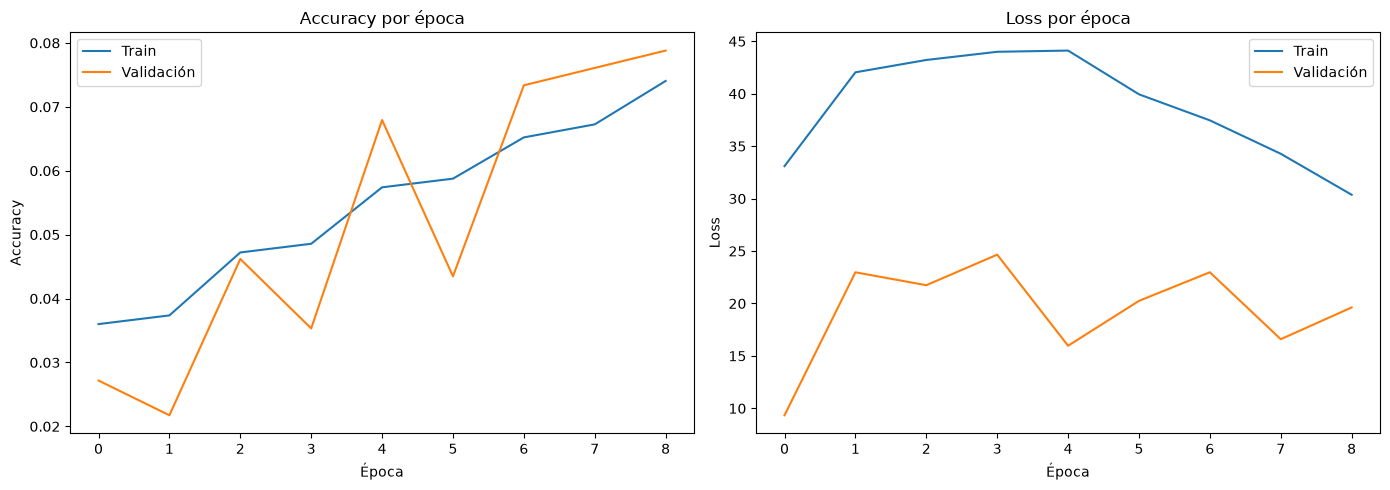

In [15]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(historia1.history['accuracy'], label='Train')
plt.plot(historia1.history['val_accuracy'], label='Validación')
plt.title('Accuracy por época')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(historia1.history['loss'], label='Train')
plt.plot(historia1.history['val_loss'], label='Validación')
plt.title('Loss por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
test_loss, test_acc = modelo1.evaluate(test_ds_prep)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0190 - loss: 9.2245
Test accuracy: 0.0190
Test loss: 9.2245


In [18]:
print("Últimas accuracy train:", historia1.history['accuracy'][-5:])
print("Últimas accuracy val:", historia1.history['val_accuracy'][-5:])
print("Número de épocas completadas:", len(historia1.history['accuracy']))

Últimas accuracy train: [0.05740489065647125, 0.05876358598470688, 0.06521739065647125, 0.06725543737411499, 0.07404891401529312]
Últimas accuracy val: [0.0679347813129425, 0.043478261679410934, 0.07336956262588501, 0.07608695328235626, 0.07880435138940811]
Número de épocas completadas: 9


In [19]:
image_batch, label_batch = next(iter(test_ds_prep))
print("Shape de imágenes:", image_batch.shape)
print("Shape de labels:", label_batch.shape)
print("Valores de labels (deben ser enteros 0-36):", label_batch.numpy()[:10])
print("Rango de píxeles en test:", image_batch.numpy().min(), image_batch.numpy().max())

Shape de imágenes: (32, 160, 160, 3)
Shape de labels: (32,)
Valores de labels (deben ser enteros 0-36): [ 6  3  1 19  9 16 27 17 14 12]
Rango de píxeles en test: 0.0 1.0


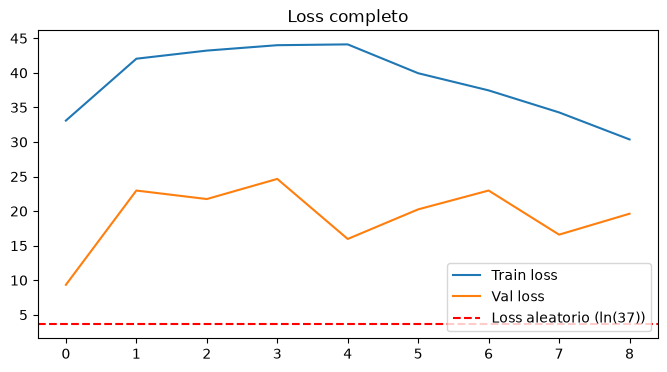

Primeras 5 loss (train): [33.09658432006836, 42.04435729980469, 43.220008850097656, 44.00086975097656, 44.117244720458984]
¿Algún NaN en loss? False


In [20]:
plt.figure(figsize=(8,4))
plt.plot(historia1.history['loss'], label='Train loss')
plt.plot(historia1.history['val_loss'], label='Val loss')
plt.axhline(y=np.log(37), color='r', linestyle='--', label='Loss aleatorio (ln(37))')
plt.legend()
plt.title('Loss completo')
plt.show()

print("Primeras 5 loss (train):", historia1.history['loss'][:5])
print("¿Algún NaN en loss?", any(np.isnan(historia1.history['loss'])))

In [21]:
modelo1b = crear_modelo_cnn()

modelo1b.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

historia1b = modelo1b.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=10,  # solo 10 para probar rápido si mejora
    callbacks=[early_stop]
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 129ms/step - accuracy: 0.0374 - loss: 11.2364 - val_accuracy: 0.0190 - val_loss: 4.0886
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - accuracy: 0.0560 - loss: 12.5478 - val_accuracy: 0.0516 - val_loss: 4.9713
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - accuracy: 0.0622 - loss: 12.9633 - val_accuracy: 0.0543 - val_loss: 5.4924
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - accuracy: 0.0584 - loss: 13.2179 - val_accuracy: 0.0598 - val_loss: 5.9091
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - accuracy: 0.0730 - loss: 13.5007 - val_accuracy: 0.0679 - val_loss: 5.7437
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - accuracy: 0.0812 - loss: 13.6660 - val_accuracy: 0.1359 - val_loss: 5.2135
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - accuracy: 0.0737 - loss: 14.0009 - val_accuracy: 0.1766 - val_loss: 5.5305
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - accuracy: 0.0829 - loss: 14.3777 - 

In [22]:
modelo1 = crear_modelo_cnn()

modelo1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint = ModelCheckpoint(
    'modelo1_mejor.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

historia1 = modelo1.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=60,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/60
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.0340 - loss: 11.1891
Epoch 1: val_accuracy improved from None to 0.03804, saving model to modelo1_mejor.keras

Epoch 1: finished saving model to modelo1_mejor.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 131ms/step - accuracy: 0.0340 - loss: 11.1891 - val_accuracy: 0.0380 - val_loss: 3.8533
Epoch 2/60
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.0442 - loss: 12.5158
Epoch 2: val_accuracy did not improve from 0.03804
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - accuracy: 0.0442 - loss: 12.5158 - val_accuracy: 0.0299 - val_loss: 4.2151
Epoch 3/60
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.0591 - loss: 13.1187
Epoch 3: val_accuracy did not improve from 0.03804
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - accuracy: 0.0591 - loss: 13.1187 - val_accuracy: 0.0353 - val_loss: 5.3477
Epoch 4/60
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.0690 - loss: 13.2934
Epoch 4: val_accuracy improved from 0.03804 to 0.

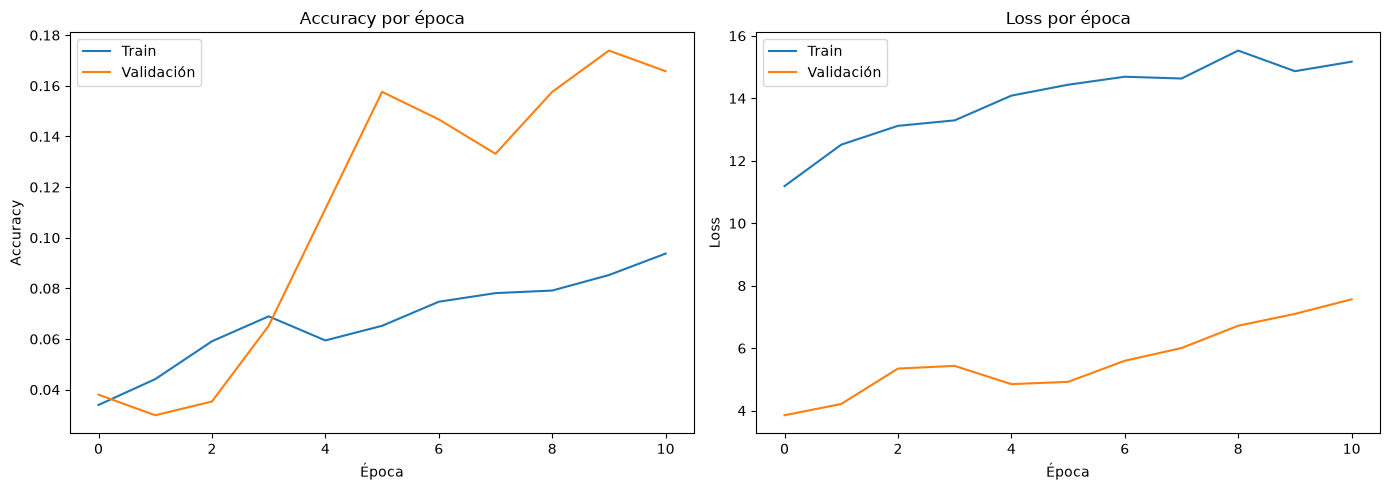

Número de épocas completadas: 11
Mejor val_accuracy: 0.17391304671764374


In [23]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(historia1.history['accuracy'], label='Train')
plt.plot(historia1.history['val_accuracy'], label='Validación')
plt.title('Accuracy por época')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(historia1.history['loss'], label='Train')
plt.plot(historia1.history['val_loss'], label='Validación')
plt.title('Loss por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

print("Número de épocas completadas:", len(historia1.history['accuracy']))
print("Mejor val_accuracy:", max(historia1.history['val_accuracy']))

In [24]:
test_loss, test_acc = modelo1.evaluate(test_ds_prep)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0163 - loss: 3.8250  
Test accuracy: 0.0163
Test loss: 3.8250


In [25]:
print("Última accuracy train:", historia1.history['accuracy'][-1])
print("Última accuracy val:", historia1.history['val_accuracy'][-1])
print("Mejor accuracy train:", max(historia1.history['accuracy']))
print("Mejor accuracy val:", max(historia1.history['val_accuracy']))

Última accuracy train: 0.09375
Última accuracy val: 0.16576087474822998
Mejor accuracy train: 0.09375
Mejor accuracy val: 0.17391304671764374


In [43]:
train_acc1 = max(historia1.history['accuracy'])
val_acc1 = max(historia1.history['val_accuracy'])
gap1 = train_acc1 - val_acc1

resultados_modelo1 = {
    'nombre': 'CNN propia (modelo 1)',
    'train_acc': max(historia1.history['accuracy']),
    'val_acc': max(historia1.history['val_accuracy']),
    'test_acc': test_acc,
    'test_loss': test_loss,
    'overfitting': True,  # gap train/val ~18-20 puntos porcentuales
    'epocas': len(historia1.history['accuracy'])
}
print(resultados_modelo1)
gap1

{'nombre': 'CNN propia (modelo 1)', 'train_acc': 0.09375, 'val_acc': 0.17391304671764374, 'test_acc': 0.016304347664117813, 'test_loss': 3.8250272274017334, 'overfitting': True, 'epocas': 11}


-0.08016304671764374

In [27]:
from keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # congelamos los pesos preentrenados

modelo2 = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation,
    layers.Rescaling(2.0, offset=-1),  # MobileNetV2 espera píxeles en [-1, 1], no [0, 1]
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(37, activation='softmax')
])

modelo2.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 37)             │        47,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305,381 (8.79 MB)

 Trainable params: 47,397 (185.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [28]:
modelo2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),  # LR más alto porque solo entrena la última capa
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint2 = ModelCheckpoint(
    'modelo2_mejor.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop2 = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

historia2 = modelo2.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=30,
    callbacks=[checkpoint2, early_stop2]
)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.4912 - loss: 1.8773
Epoch 1: val_accuracy improved from None to 0.85598, saving model to modelo2_mejor.keras

Epoch 1: finished saving model to modelo2_mejor.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - accuracy: 0.4912 - loss: 1.8773 - val_accuracy: 0.8560 - val_loss: 0.6307
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7931 - loss: 0.7150
Epoch 2: val_accuracy improved from 0.85598 to 0.86685, saving model to modelo2_mejor.keras

Epoch 2: finished saving model to modelo2_mejor.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.7931 - loss: 0.7150 - val_accuracy: 0.8668 - val_loss: 0.4745
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8240 - loss: 0.5495
Epoch 3: val_accuracy improved from 0.86685 to 0.89674, saving model to modelo2_mejor.keras

Epoch 3: finished saving model to modelo2_mejor.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.8240 - loss: 0.5495 

In [29]:
test_loss2, test_acc2 = modelo2.evaluate(test_ds_prep)
print(f"Test accuracy: {test_acc2:.4f}")
print(f"Test loss: {test_loss2:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8696 - loss: 0.4300
Test accuracy: 0.8696
Test loss: 0.4300


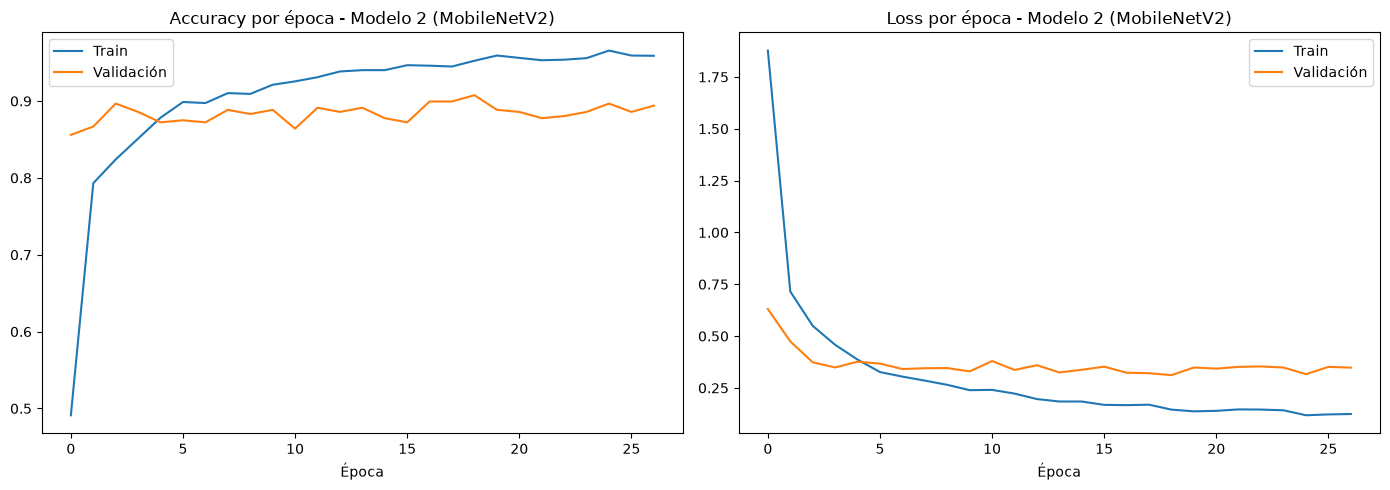

In [30]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(historia2.history['accuracy'], label='Train')
plt.plot(historia2.history['val_accuracy'], label='Validación')
plt.title('Accuracy por época - Modelo 2 (MobileNetV2)')
plt.xlabel('Época')
plt.legend()

plt.subplot(1,2,2)
plt.plot(historia2.history['loss'], label='Train')
plt.plot(historia2.history['val_loss'], label='Validación')
plt.title('Loss por época - Modelo 2 (MobileNetV2)')
plt.xlabel('Época')
plt.legend()

plt.tight_layout()
plt.show()

In [42]:
train_acc2 = max(historia2.history['accuracy'])
val_acc2 = max(historia2.history['val_accuracy'])
gap2 = train_acc2 - val_acc2

resultados_modelo2 = {
    'nombre': 'MobileNetV2 - Transfer Learning (modelo 2)',
    'train_acc': max(historia2.history['accuracy']),
    'val_acc': max(historia2.history['val_accuracy']),
    'test_acc': test_acc2,
    'test_loss': test_loss2,
    'overfitting': False,  # brecha train/val moderada (~6-7 puntos)
    'epocas': len(historia2.history['accuracy'])
}
print(resultados_modelo2)
gap2

{'nombre': 'MobileNetV2 - Transfer Learning (modelo 2)', 'train_acc': 0.965692937374115, 'val_acc': 0.907608687877655, 'test_acc': 0.8695651888847351, 'test_loss': 0.4300103485584259, 'overfitting': False, 'epocas': 27}


0.05808424949645996

# Modelo 3 — EfficientNetB0 (Transfer Learning)

En este tercer experimento se utiliza **EfficientNetB0** preentrenada con ImageNet. Se mantienen congelados los pesos convolucionales y se entrena únicamente un clasificador final para las 37 razas.

> **Nota de preprocesamiento:** `train_ds_prep`, `val_ds_prep` y `test_ds_prep` ya contienen imágenes normalizadas al rango `[0, 1]`. EfficientNetB0 de Keras incorpora internamente el reescalado esperado para entradas en `[0, 255]`, por lo que antes del backbone se usa `Rescaling(255.0)` para recuperar dicha escala.

In [32]:
from keras.applications import EfficientNetB0

base_model3 = EfficientNetB0(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model3.trainable = False

modelo3 = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation,
    layers.Rescaling(255.0),  # nuestros datasets vienen en [0,1]; EfficientNet espera [0,255]
    base_model3,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.35),
    layers.Dense(37, activation='softmax')
])

modelo3.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 5, 5, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 37)             │        47,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,096,968 (15.63 MB)

 Trainable params: 47,397 (185.14 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [33]:
modelo3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint3 = ModelCheckpoint(
    '../keras/modelo3_mejor.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop3 = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

historia3 = modelo3.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=30,
    callbacks=[checkpoint3, early_stop3]
)

Epoch 1/30


/Users/fvcg/projects/uni-cognit-systems/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5156 - loss: 2.1199
Epoch 1: val_accuracy improved from None to 0.84239, saving model to ../keras/modelo3_mejor.keras

Epoch 1: finished saving model to ../keras/modelo3_mejor.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 109ms/step - accuracy: 0.5156 - loss: 2.1199 - val_accuracy: 0.8424 - val_loss: 0.8976
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.7853 - loss: 0.8780
Epoch 2: val_accuracy improved from 0.84239 to 0.87772, saving model to ../keras/modelo3_mejor.keras

Epoch 2: finished saving model to ../keras/modelo3_mejor.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.7853 - loss: 0.8780 - val_accuracy: 0.8777 - val_loss: 0.5362
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8383 - loss: 0.6369
Epoch 3: val_accuracy improved from 0.87772 to 0.89130, saving model to ../keras/modelo3_mejor.keras

Epoch 3: finished saving model to ../keras/modelo3_mejor.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 

In [34]:
test_loss3, test_acc3 = modelo3.evaluate(test_ds_prep)
print(f"Test accuracy Modelo 3: {test_acc3:.4f}")
print(f"Test loss Modelo 3: {test_loss3:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.9022 - loss: 0.3331
Test accuracy Modelo 3: 0.9022
Test loss Modelo 3: 0.3331


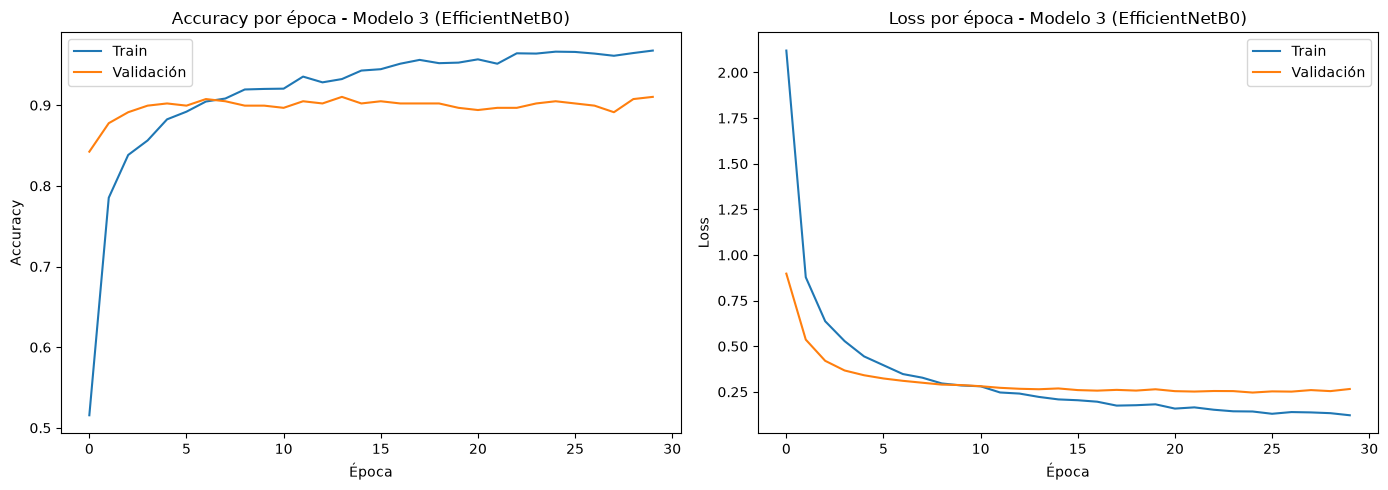

In [35]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(historia3.history['accuracy'], label='Train')
plt.plot(historia3.history['val_accuracy'], label='Validación')
plt.title('Accuracy por época - Modelo 3 (EfficientNetB0)')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(historia3.history['loss'], label='Train')
plt.plot(historia3.history['val_loss'], label='Validación')
plt.title('Loss por época - Modelo 3 (EfficientNetB0)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [36]:
train_acc3 = max(historia3.history['accuracy'])
val_acc3 = max(historia3.history['val_accuracy'])
gap3 = train_acc3 - val_acc3

resultados_modelo3 = {
    'nombre': 'EfficientNetB0 - Transfer Learning (modelo 3)',
    'train_acc': train_acc3,
    'val_acc': val_acc3,
    'test_acc': test_acc3,
    'test_loss': test_loss3,
    'gap_train_val': gap3,
    'epocas': len(historia3.history['accuracy'])
}
print(resultados_modelo3)
print(f"Brecha train-validación: {gap3:.4f}")

{'nombre': 'EfficientNetB0 - Transfer Learning (modelo 3)', 'train_acc': 0.9677309989929199, 'val_acc': 0.9103260636329651, 'test_acc': 0.9021739363670349, 'test_loss': 0.3330969512462616, 'gap_train_val': 0.057404935359954834, 'epocas': 30}
Brecha train-validación: 0.0574


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step
Shape y_true: (368,)
Shape y_pred: (368,)


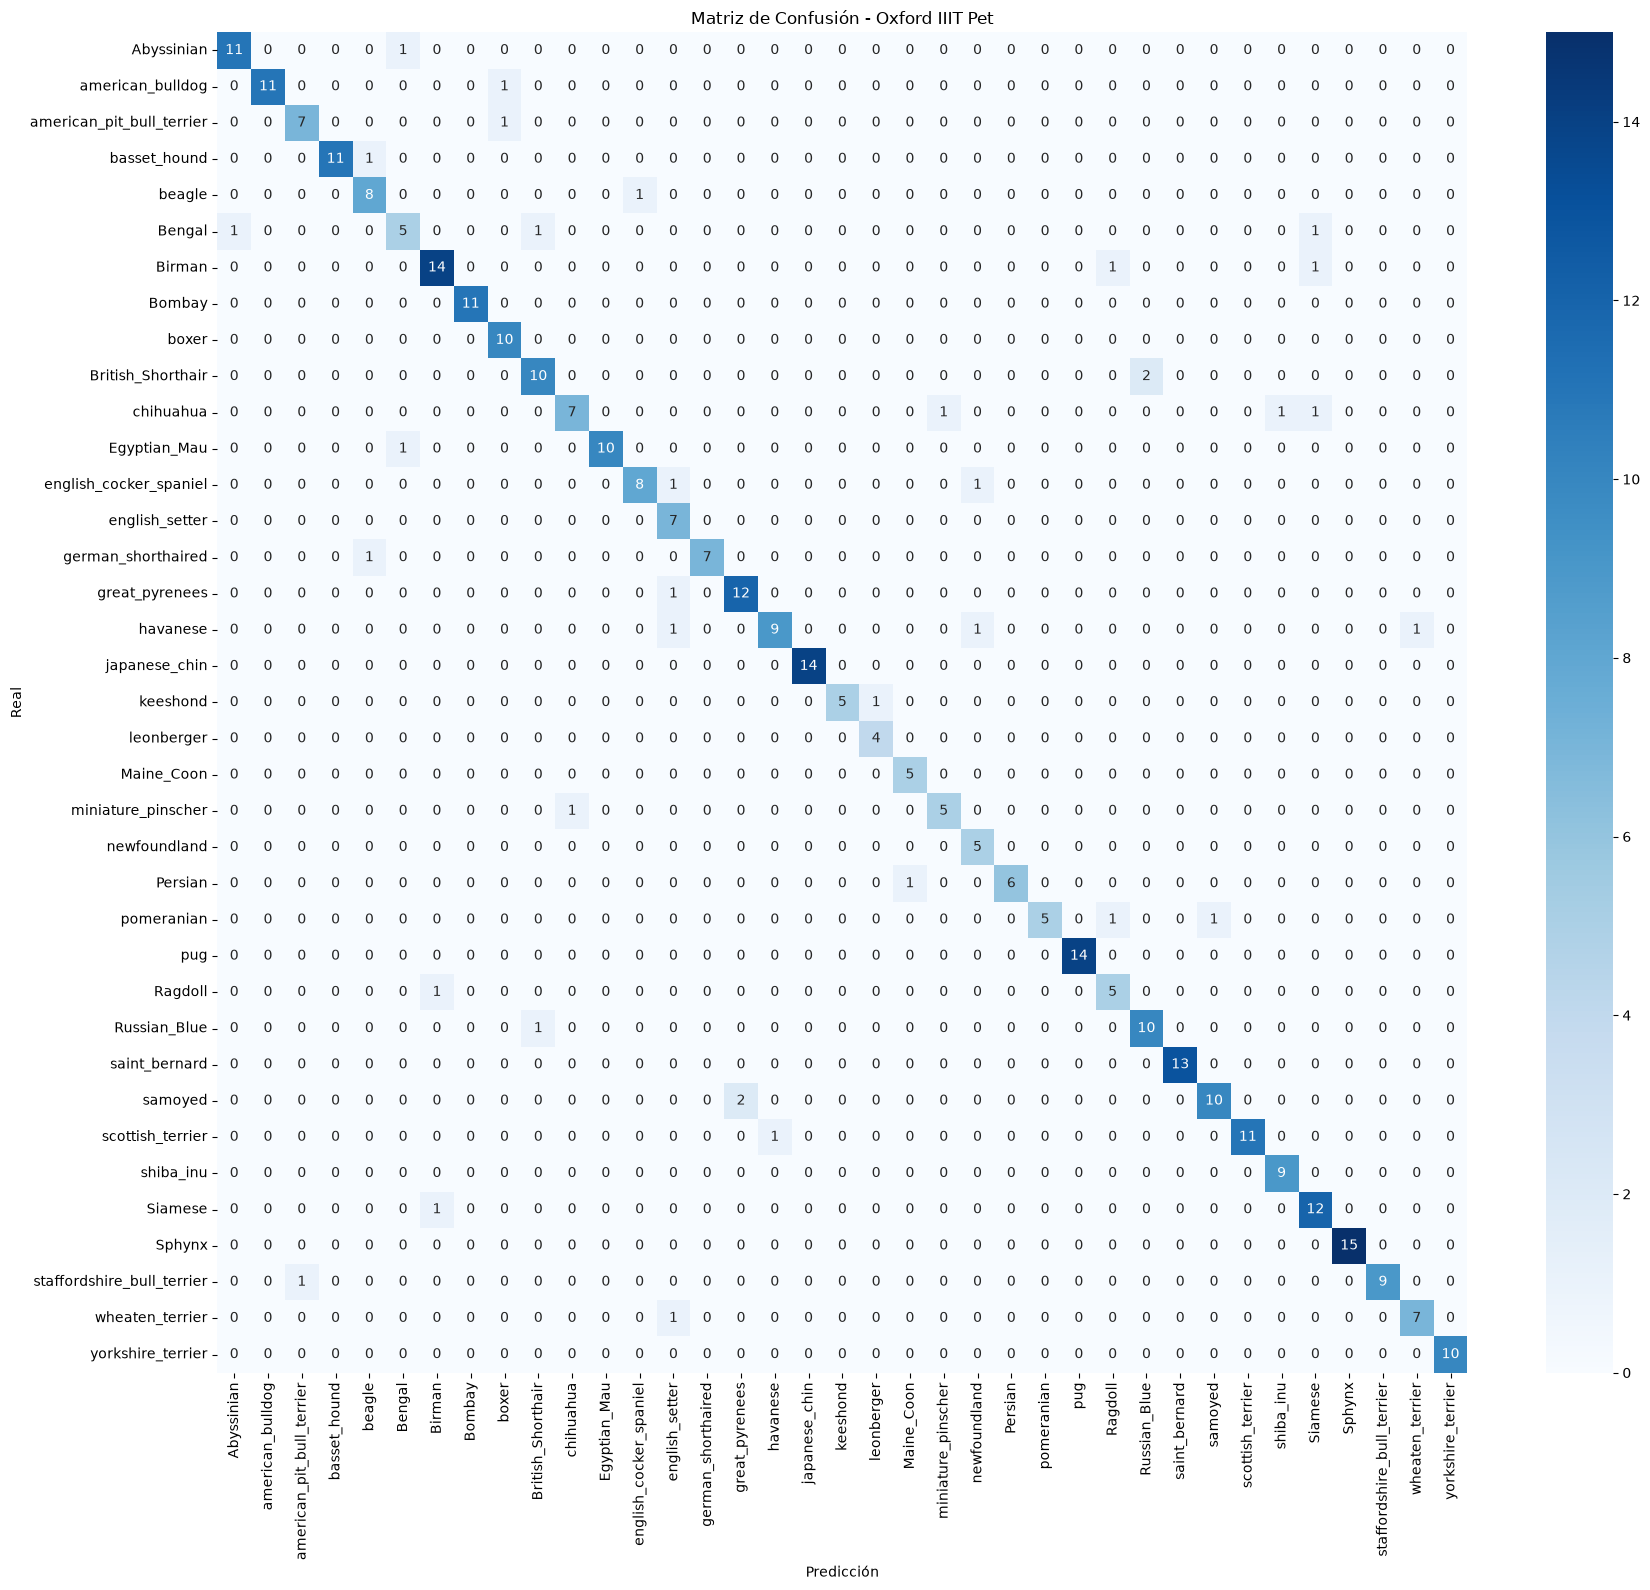

In [46]:
# Predicciones (probabilidades)
y_pred_probs3 = modelo3.predict(test_ds_prep, verbose=1)

# Convertir a clases (índice con mayor probabilidad)
y_pred3 = np.argmax(y_pred_probs3, axis=1)

# Etiquetas reales
y_true3 = np.concatenate([y.numpy() for _, y in test_ds_prep], axis=0)

print("Shape y_true:", y_true3.shape)
print("Shape y_pred:", y_pred3.shape)

class_names = info.features['label'].names

# Matriz de confusión
cm = confusion_matrix(y_true3, y_pred3)

# Visualización como heatmap
plt.figure(figsize=(18, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Oxford IIIT Pet')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [49]:
report = classification_report(
    y_true3,
    y_pred3,
    target_names=class_names,
    digits=4
)
print(report)

                            precision    recall  f1-score   support

                Abyssinian     0.9167    0.9167    0.9167        12
          american_bulldog     1.0000    0.9167    0.9565        12
 american_pit_bull_terrier     0.8750    0.8750    0.8750         8
              basset_hound     1.0000    0.9167    0.9565        12
                    beagle     0.8000    0.8889    0.8421         9
                    Bengal     0.7143    0.6250    0.6667         8
                    Birman     0.8750    0.8750    0.8750        16
                    Bombay     1.0000    1.0000    1.0000        11
                     boxer     0.8333    1.0000    0.9091        10
         British_Shorthair     0.8333    0.8333    0.8333        12
                 chihuahua     0.8750    0.7000    0.7778        10
              Egyptian_Mau     1.0000    0.9091    0.9524        11
    english_cocker_spaniel     0.8889    0.8000    0.8421        10
            english_setter     0.6364    1.0000

In [48]:
import pandas as pd
report_dict = classification_report(
    y_true3, y_pred3,
    target_names=class_names,
    output_dict=True
)

df_report = pd.DataFrame(report_dict).transpose()
df_report  # En Jupyter/Colab se renderiza como tabla HTML

,precision,recall,f1-score,support
Abyssinian,0.916667,0.916667,0.916667,12.000000
american_bulldog,1.000000,0.916667,0.956522,12.000000
american_pit_bull_terrier,0.875000,0.875000,0.875000,8.000000
basset_hound,1.000000,0.916667,0.956522,12.000000
beagle,0.800000,0.888889,0.842105,9.000000
Bengal,0.714286,0.625000,0.666667,8.000000
Birman,0.875000,0.875000,0.875000,16.000000
Bombay,1.000000,1.000000,1.000000,11.000000
boxer,0.833333,1.000000,0.909091,10.000000
British_Shorthair,0.833333,0.833333,0.833333,12.000000


### Interpretación del Modelo 3

Al finalizar el entrenamiento, comparar el accuracy de entrenamiento y validación junto con sus curvas de pérdida. Una brecha pequeña y curvas estables sugieren buena generalización; una brecha creciente puede indicar sobreajuste. El resultado de test debe utilizarse como evaluación final y compararse con los modelos anteriores.

# Modelo 4 — Fine-tuning de MobileNetV2

El Modelo 2 utiliza MobileNetV2 como extractor de características completamente congelado. En este cuarto experimento se realiza **fine-tuning**: se descongelan únicamente las últimas capas del backbone preentrenado y se continúa el entrenamiento con una tasa de aprendizaje muy baja.

Esto permite adaptar características de alto nivel de ImageNet al problema específico de clasificación de razas, sin modificar agresivamente los pesos preentrenados.

In [37]:
# Partimos del MobileNetV2 ya entrenado en el Modelo 2.
# base_model es el backbone creado en la sección anterior y modelo2 contiene sus pesos aprendidos.

base_model.trainable = True

# Congelamos todas las capas salvo las últimas 30.
for layer in base_model.layers[:-30]:
    layer.trainable = False

# En datasets relativamente pequeños conviene mantener BatchNormalization congelado
# durante fine-tuning para no desestabilizar sus estadísticas aprendidas.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print('Capas totales del backbone:', len(base_model.layers))
print('Capas entrenables del backbone:', sum(layer.trainable for layer in base_model.layers))

Capas totales del backbone: 154
Capas entrenables del backbone: 19


In [38]:
# Tras cambiar el atributo trainable es obligatorio recompilar el modelo.
modelo4 = modelo2

modelo4.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint4 = ModelCheckpoint(
    'modelo4_mejor.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop4 = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

reduce_lr4 = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

historia4 = modelo4.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=20,
    callbacks=[checkpoint4, early_stop4, reduce_lr4]
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9497 - loss: 0.1444
Epoch 1: val_accuracy improved from None to 0.89402, saving model to modelo4_mejor.keras

Epoch 1: finished saving model to modelo4_mejor.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step - accuracy: 0.9497 - loss: 0.1444 - val_accuracy: 0.8940 - val_loss: 0.3355 - learning_rate: 1.0000e-05
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9575 - loss: 0.1296
Epoch 2: val_accuracy did not improve from 0.89402
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.9575 - loss: 0.1296 - val_accuracy: 0.8913 - val_loss: 0.3436 - learning_rate: 1.0000e-05
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9643 - loss: 0.1164
Epoch 3: val_accuracy did not improve from 0.89402
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.9643 - loss: 0.1164 - val_accuracy: 0.8886 - val_loss: 0.3485 - learning_rate: 1.0000e-05
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9

In [39]:
test_loss4, test_acc4 = modelo4.evaluate(test_ds_prep)
print(f"Test accuracy Modelo 4: {test_acc4:.4f}")
print(f"Test loss Modelo 4: {test_loss4:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8668 - loss: 0.4354
Test accuracy Modelo 4: 0.8668
Test loss Modelo 4: 0.4354


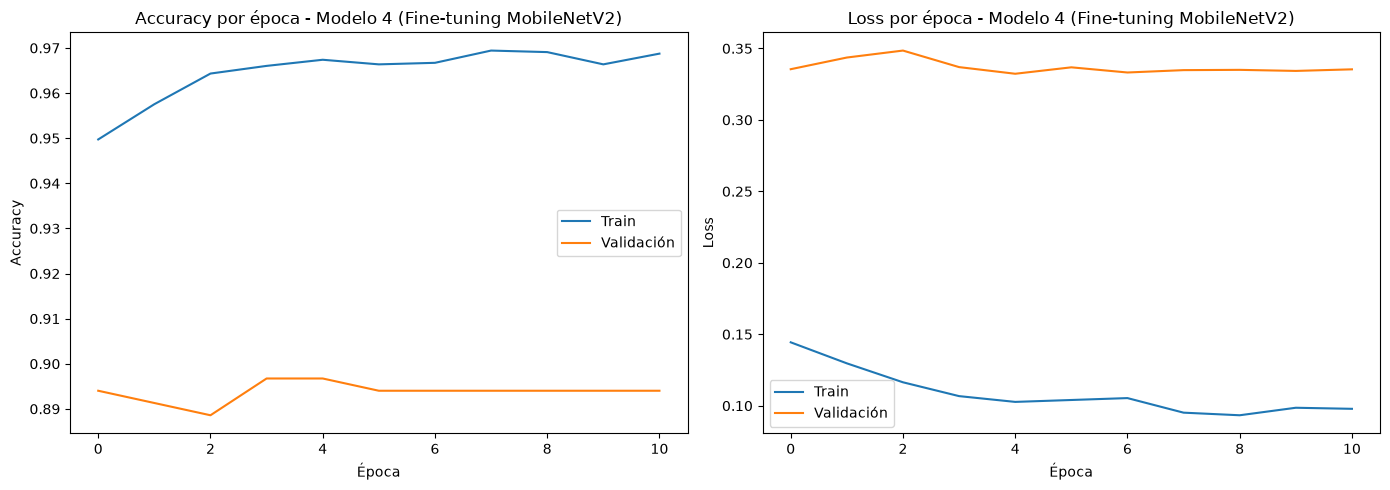

In [40]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(historia4.history['accuracy'], label='Train')
plt.plot(historia4.history['val_accuracy'], label='Validación')
plt.title('Accuracy por época - Modelo 4 (Fine-tuning MobileNetV2)')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(historia4.history['loss'], label='Train')
plt.plot(historia4.history['val_loss'], label='Validación')
plt.title('Loss por época - Modelo 4 (Fine-tuning MobileNetV2)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [41]:
train_acc4 = max(historia4.history['accuracy'])
val_acc4 = max(historia4.history['val_accuracy'])
gap4 = train_acc4 - val_acc4

resultados_modelo4 = {
    'nombre': 'MobileNetV2 - Fine-tuning (modelo 4)',
    'train_acc': train_acc4,
    'val_acc': val_acc4,
    'test_acc': test_acc4,
    'test_loss': test_loss4,
    'gap_train_val': gap4,
    'epocas': len(historia4.history['accuracy'])
}
print(resultados_modelo4)
print(f"Brecha train-validación: {gap4:.4f}")

{'nombre': 'MobileNetV2 - Fine-tuning (modelo 4)', 'train_acc': 0.9694293737411499, 'val_acc': 0.89673912525177, 'test_acc': 0.866847813129425, 'test_loss': 0.43538644909858704, 'gap_train_val': 0.07269024848937988, 'epocas': 11}
Brecha train-validación: 0.0727


### Interpretación del Modelo 4

El fine-tuning debería compararse directamente con el Modelo 2. Si mejora el accuracy de validación/test sin aumentar de forma marcada la brecha entre entrenamiento y validación, la adaptación de las capas superiores fue beneficiosa. Si la validación empeora mientras entrenamiento continúa aumentando, puede existir sobreajuste y sería preferible conservar el Modelo 2.

### Modelo 5


In [50]:
def crear_modelo_fc():
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        data_augmentation,
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(37, activation='softmax')
    ])
    return model

modelo5 = crear_modelo_fc()
modelo5.summary()

modelo5.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 76800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │    39,322,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 37)             │         9,509 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,466,021 (150.55 MB)

 Trainable params: 39,464,485 (150.55 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [51]:
checkpoint5 = ModelCheckpoint(
    'modelo5_mejor.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop5 = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

historia5 = modelo5.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=50,
    callbacks=[checkpoint5, early_stop5]
)


Epoch 1/50


/Users/fvcg/projects/uni-cognit-systems/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.0336 - loss: 4.8018
Epoch 1: val_accuracy improved from None to 0.04076, saving model to modelo5_mejor.keras

Epoch 1: finished saving model to modelo5_mejor.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - accuracy: 0.0336 - loss: 4.8018 - val_accuracy: 0.0408 - val_loss: 4.7022
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.0472 - loss: 4.5412
Epoch 2: val_accuracy improved from 0.04076 to 0.04620, saving model to modelo5_mejor.keras

Epoch 2: finished saving model to modelo5_mejor.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.0472 - loss: 4.5412 - val_accuracy: 0.0462 - val_loss: 3.7762
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.0533 - loss: 4.3986
Epoch 3: val_accuracy improved from 0.04620 to 0.05435, saving model to modelo5_mejor.keras

Epoch 3: finished saving model to modelo5_mejor.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.0533 - loss: 4.3986 - val_accura

In [53]:
test_loss5, test_acc5 = modelo5.evaluate(test_ds_prep)
print(f"Test accuracy: {test_acc5:.4f}")
print(f"Test loss: {test_loss5:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1087 - loss: 3.2330
Test accuracy: 0.1087
Test loss: 3.2330


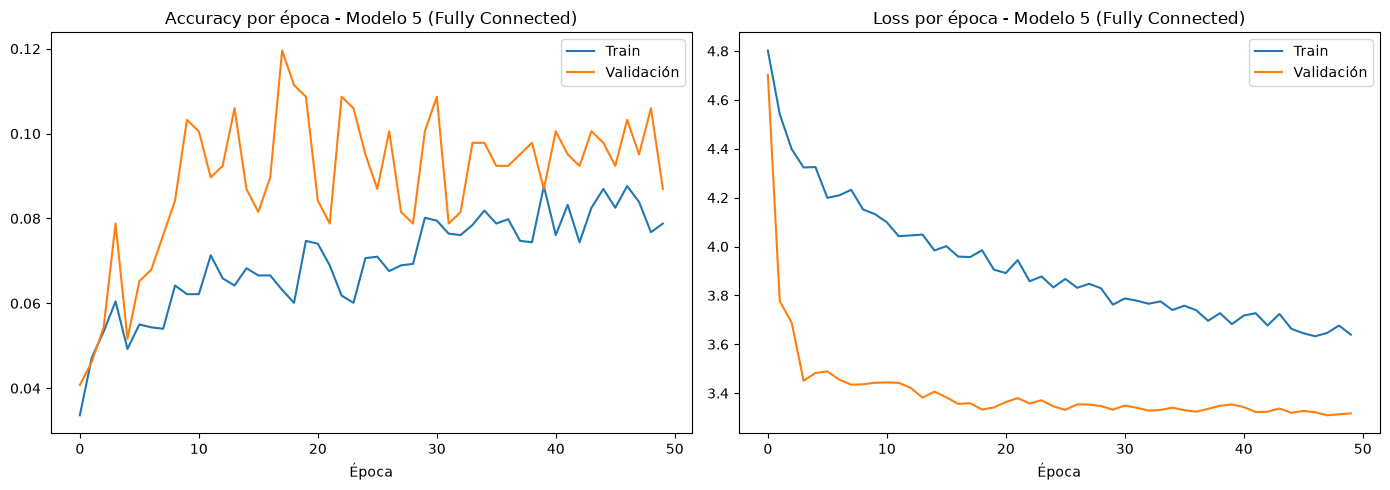

In [54]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(historia5.history['accuracy'], label='Train')
plt.plot(historia5.history['val_accuracy'], label='Validación')
plt.title('Accuracy por época - Modelo 5 (Fully Connected)')
plt.xlabel('Época')
plt.legend()

plt.subplot(1,2,2)
plt.plot(historia5.history['loss'], label='Train')
plt.plot(historia5.history['val_loss'], label='Validación')
plt.title('Loss por época - Modelo 5 (Fully Connected)')
plt.xlabel('Época')
plt.legend()

plt.tight_layout()
plt.show()


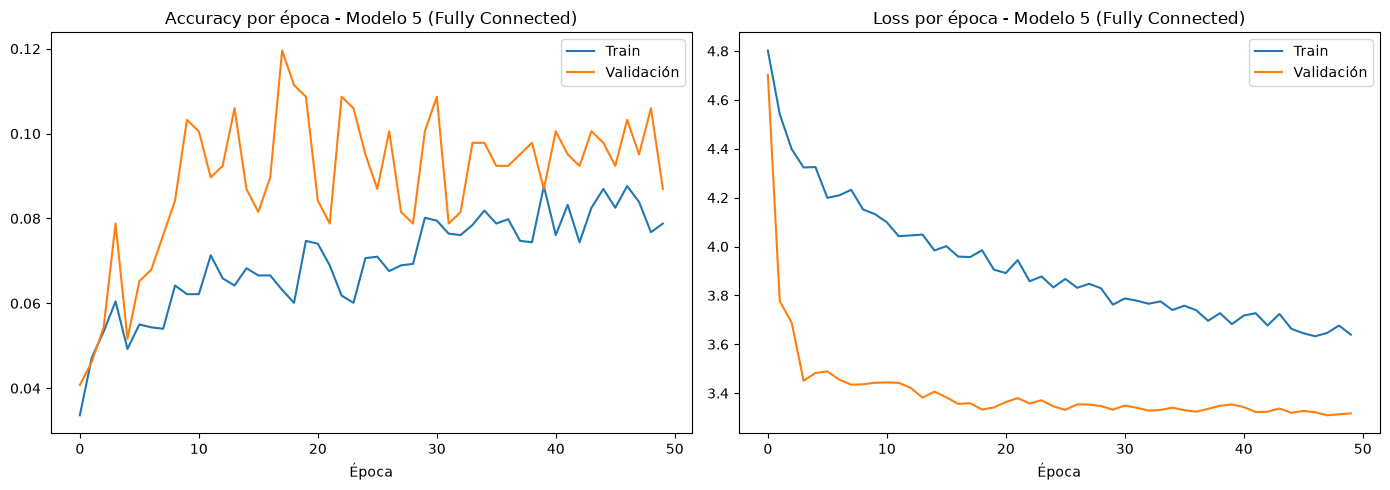

{'nombre': 'Fully Connected (modelo 5)', 'train_acc': 0.08763586729764938, 'val_acc': 0.1195652186870575, 'test_acc': 0.10869564861059189, 'test_loss': 3.2330498695373535, 'gap_train_val': -0.03192935138940811, 'epocas': 50}


In [55]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(historia5.history['accuracy'], label='Train')
plt.plot(historia5.history['val_accuracy'], label='Validación')
plt.title('Accuracy por época - Modelo 5 (Fully Connected)')
plt.xlabel('Época')
plt.legend()

plt.subplot(1,2,2)
plt.plot(historia5.history['loss'], label='Train')
plt.plot(historia5.history['val_loss'], label='Validación')
plt.title('Loss por época - Modelo 5 (Fully Connected)')
plt.xlabel('Época')
plt.legend()

plt.tight_layout()
plt.show()


train_acc5 = max(historia5.history['accuracy'])
val_acc5 = max(historia5.history['val_accuracy'])
gap5 = train_acc5 - val_acc5

resultados_modelo5 = {
    'nombre': 'Fully Connected (modelo 5)',
    'train_acc': train_acc5,
    'val_acc': val_acc5,
    'test_acc': test_acc5,
    'test_loss': test_loss5,
    'gap_train_val': gap5,
    'epocas': len(historia5.history['accuracy'])
}
print(resultados_modelo5)